# Notebook 5 — Model Development

**Dissertation:** *An Explainable AI-driven Spatial Intelligence Framework for Crime Hotspot Prediction*

This notebook develops the predictive core of the framework. Notebook 4 delivered a leakage-safe cell-month modelling table (924 rows, nine justified features, real OpenStreetMap context); Notebook 5 uses it to build and validate the **graduated model ladder** specified in the Project Design Document. In keeping with the guiding principle, the aim is *model development and honest comparison*, not accuracy-maximisation: each model is trained under a temporally-correct protocol, compared against a naive benchmark, and prepared for the walk-forward evaluation and SHAP explainability that follow.


## 1. Methodology and Its Justification

### 1.1 What this notebook does, and what it defers

Notebook 5 has a deliberately bounded scope: it establishes the four models, fixes a leakage-safe validation protocol, trains every model under that protocol on the real data, and reports genuine comparative performance against the baseline. The **exhaustive evaluation battery** (per-fold uncertainty, spatial block validation, calibration and error mapping) and the **SHAP explanation layer** are the subject of the next stage; this notebook is written so those stages plug directly into the artefacts it saves. This separation mirrors the Project Design Document's distinction between the modelling strategy (§6) and the validation and explainability strategies (§7–§8).

### 1.2 Connection to the Literature Review and the Project Design Document

The modelling design is a direct implementation of the reviewed literature. The choice to predict a cell's hotspot status from its own recent history and its neighbours' rests on the near-repeat and hotspot-persistence findings of Ratcliffe (2005) and Chainey, Tompson and Uhlig (2008); the addition of built-environment context follows the predictive gains reported by Zhang et al. (2020, 2022). The decision to include a transparent linear model alongside ensembles reflects the interpretable-ML literature's argument that a simple model is often competitive and should be the reference point (the "interpretable machine learning" strand of Chapter 2), while the selection of a gradient-boosted-tree model as the most complex rung is what makes the later exact TreeSHAP explanation possible (Lundberg and Lee, 2017). The **walk-forward** protocol, **class-weighting** for imbalance, and **imbalance-aware metrics** are taken verbatim from §7 of the Project Design Document, and the whole notebook obeys its §11 guiding principle that performance is always reported beside its baseline and its explanation.

### 1.3 Why each model is included (the ladder)

The four models form a deliberate progression from transparent benchmark to explainable state-of-the-art, so that every increase in complexity must *earn its place* by beating the rung below:

- **Persistence (naive baseline).** Predicts that a cell will be a hotspot next month if it was one this month. Because Notebook 3 showed hotspots are highly persistent, this is a genuinely strong benchmark — and the honest bar every learned model must clear to justify itself. Without it, high accuracy would be meaningless.
- **Logistic Regression.** A fully transparent linear model whose coefficients are directly interpretable. It tests how far a simple, explainable model can go, and serves as the reference the interpretable-ML literature demands.
- **Random Forest.** A bagged tree ensemble that captures non-linearities and interactions the linear model cannot, while remaining robust on small, noisy data with minimal tuning.
- **XGBoost.** A gradient-boosted-tree model representing the state of the art for tabular problems, and the model for which SHAP admits an exact, efficient (TreeSHAP) formulation. This makes it a strong *candidate* for the explanation layer, but it is **not** designated the final model in this notebook: which model is carried into the SHAP stage is decided in Notebook 6 on the full balance of predictive performance, calibration, operational usefulness and explainability — not on ROC-AUC alone, and not presupposed here.

### 1.4 Feasibility within an MSc dissertation timeframe

The design is intentionally proportionate. The modelling table is small (924 rows, nine features), so every model trains in seconds on a laptop and the entire walk-forward completes in under a minute — leaving time for the interpretation and write-up that carry the marks. Four well-understood algorithms with library-standard implementations avoid the open-ended tuning and infrastructure that would put a larger design at risk, while still spanning the full interpretability–complexity spectrum the research question requires. Complexity is spent where it advances the argument (a single explainable ensemble) and saved everywhere else, exactly as the guiding principle directs.


## 2. Setup and Loading the Modelling Table

Only the artefacts of Notebook 4 are consumed. The nine features are exactly those retained after the redundancy pruning documented there; the target `y` is the leakage-safe within-month hotspot label; and the OpenStreetMap contextual block is the real, populated version.


In [ ]:
from pathlib import Path
import os, json, math, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.dpi"]=110; plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3
NAVY="#2E5496"; CRIMSON="#B03A3A"; GOLD="#C8912B"; GREEN="#3B7A57"
PALETTE={"Persistence":"#8A8A8A","LogisticRegression":NAVY,"RandomForest":GREEN,"XGBoost":CRIMSON}

DATA_DIR=Path(os.environ.get("COL_DATA_DIR", r"C:\Users\Admin\Downloads\London_UK_Police_Data"))
PROC_DIR=Path(os.environ.get("COL_OUTPUT_DIR", str(DATA_DIR/"processed")))

model_tbl=pd.read_csv(PROC_DIR/"model_table_250m.csv")
FEATURES=["roll3_mean","trend_1","prior_hotspot_freq","neigh_lag1_sum",
          "osm_retail_density","osm_food_drink_density","osm_licensed_count",
          "osm_transport_nodes","osm_road_density_m"]
MONTHS=sorted(model_tbl["month"].unique())
osm_ok=model_tbl[[c for c in FEATURES if c.startswith("osm_")]].notna().all().all()
print(f"Modelling table: {model_tbl.shape[0]} rows x {model_tbl.shape[1]} cols")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target months: {len(MONTHS)} ({MONTHS[0]} -> {MONTHS[-1]})  |  hotspot prevalence: {100*model_tbl['y'].mean():.1f}%")
print(f"OSM contextual features populated (no NaN): {osm_ok}")
assert osm_ok, "OSM features must be populated before modelling."


Modelling table: 924 rows x 14 cols
Features (9): ['roll3_mean', 'trend_1', 'prior_hotspot_freq', 'neigh_lag1_sum', 'osm_retail_density', 'osm_food_drink_density', 'osm_licensed_count', 'osm_transport_nodes', 'osm_road_density_m']
Target months: 11 (2025-03 -> 2026-01)  |  hotspot prevalence: 13.6%
OSM contextual features populated (no NaN): True


## 3. Leakage-Safe Validation Design — Expanding-Window Walk-Forward

Crime data are a time series, so a random train/test split would let the model learn from the future — invalidating every metric. Following §7 of the Project Design Document, evaluation uses an **expanding-window walk-forward**: to predict month *t*, the model is trained only on months strictly before *t*; the window then advances by one month and the process repeats. This mirrors real operational deployment (each month one predicts the next from all history to date) and yields several genuine out-of-sample test months.

Because the panel's features were already built from prior months only (Notebook 4), and any scaling or model fitting here is performed **on the training fold alone**, no information from the target month can reach the prediction. An initial training window of four months is used before the first prediction, giving seven out-of-sample test months (2025-07 to 2026-01).


In [2]:
INIT_TRAIN = 4                                   # months of history before first prediction
TEST_MONTHS = MONTHS[INIT_TRAIN:]
def walk_forward_folds():
    for tm in TEST_MONTHS:
        tr = model_tbl[model_tbl["month"] < tm]
        te = model_tbl[model_tbl["month"] == tm]
        yield tm, tr, te
print(f"Expanding-window walk-forward: {len(TEST_MONTHS)} test folds")
for tm, tr, te in walk_forward_folds():
    print(f"  train < {tm}: {len(tr):3d} rows ({tr['month'].nunique()} months, "
          f"{tr['y'].sum():2d} hotspots)  ->  test {tm}: {len(te)} cells, {te['y'].sum()} hotspots")


Expanding-window walk-forward: 7 test folds
  train < 2025-07: 336 rows (4 months, 47 hotspots)  ->  test 2025-07: 84 cells, 10 hotspots
  train < 2025-08: 420 rows (5 months, 57 hotspots)  ->  test 2025-08: 84 cells, 11 hotspots
  train < 2025-09: 504 rows (6 months, 68 hotspots)  ->  test 2025-09: 84 cells, 13 hotspots
  train < 2025-10: 588 rows (7 months, 81 hotspots)  ->  test 2025-10: 84 cells, 11 hotspots
  train < 2025-11: 672 rows (8 months, 92 hotspots)  ->  test 2025-11: 84 cells, 11 hotspots
  train < 2025-12: 756 rows (9 months, 103 hotspots)  ->  test 2025-12: 84 cells, 11 hotspots
  train < 2026-01: 840 rows (10 months, 114 hotspots)  ->  test 2026-01: 84 cells, 12 hotspots


## 4. Preprocessing and Class-Imbalance Handling

Hotspots are a minority (~14%), so accuracy is a misleading objective and imbalance must be handled at the model level rather than by resampling (which would fabricate spatial observations). Each model therefore uses **cost-sensitive weighting** — `class_weight="balanced"` for the linear and forest models, and the equivalent `scale_pos_weight` for XGBoost — so the minority hotspot class is not ignored. Only the Logistic Regression requires feature **scaling**; it is standardised with statistics fitted on the training fold alone inside each walk-forward step, so no test-fold information leaks through the scaler. The tree models are scale-invariant and use the raw features.


## 5. The Model Ladder and Walk-Forward Training

Each learned model is defined once, with settings chosen for robustness on small data rather than aggressive tuning, and trained fresh inside every walk-forward fold. The persistence baseline needs no training: its prediction for a cell in month *t* is simply whether that cell was a hotspot in month *t−1*, reconstructed with the same within-month rule used to define the target. Out-of-fold predictions from all test months are pooled so that every metric is computed on genuine out-of-sample data.


In [3]:
# Reconstruct the monthly hotspot-label matrix for the persistence baseline
crimes = pd.read_csv(PROC_DIR/"crimes_with_grid250.csv", parse_dates=["month"])
crimes["ym"] = crimes["month"].dt.to_period("M").astype(str)
params = pd.read_csv(PROC_DIR/"grid_250m_params.csv").iloc[0]
NCOL=int(params["ncol"]); NROW=int(params["nrow"]); HOT=int(params["hotspot_percentile"])
CELLS=list(range(NROW*NCOL))
count_mx = (crimes.groupby(["cell250","ym"]).size().unstack(fill_value=0)
            .reindex(index=CELLS, fill_value=0))
ALLM=sorted(count_mx.columns)
def _monthlabel(col):
    occ=col[col>0]
    return (col*0).astype(int) if len(occ)==0 else (col>=np.percentile(occ.values,HOT)).astype(int)
LABEL_MX = count_mx.apply(_monthlabel, axis=0)          # cells x months (0/1)
def prev_month(mm): 
    i=ALLM.index(mm); return ALLM[i-1] if i>0 else None

def make_models(pos_weight):
    return {
      "LogisticRegression": (LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42), True),
      "RandomForest":       (RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                    random_state=42, n_jobs=-1), False),
      "XGBoost":            (XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                           subsample=0.9, colsample_bytree=0.9,
                                           scale_pos_weight=pos_weight, eval_metric="logloss",
                                           random_state=42), False),
    }
print("Models defined:", ["Persistence"] + list(make_models(1).keys()))


Models defined: ['Persistence', 'LogisticRegression', 'RandomForest', 'XGBoost']


In [4]:
# Walk-forward: collect pooled out-of-fold predictions + per-fold ROC/PR-AUC
oof = {m: {"y":[], "p":[], "cell":[], "month":[]} for m in
       ["Persistence","LogisticRegression","RandomForest","XGBoost"]}
per_fold = {m: [] for m in oof}

for tm, tr, te in walk_forward_folds():
    Xtr, ytr = tr[FEATURES].values, tr["y"].values
    Xte, yte = te[FEATURES].values, te["y"].values
    pos_weight = (ytr==0).sum()/max(1,(ytr==1).sum())

    # Persistence baseline
    pm = prev_month(tm)
    p_base = te["cell"].map(lambda c: int(LABEL_MX.loc[c, pm])).values.astype(float)
    # Learned models
    preds = {"Persistence": p_base}
    for name,(clf,scale) in make_models(pos_weight).items():
        Xtr_, Xte_ = Xtr, Xte
        if scale:
            sc=StandardScaler().fit(Xtr); Xtr_=sc.transform(Xtr); Xte_=sc.transform(Xte)
        clf.fit(Xtr_, ytr)
        preds[name]=clf.predict_proba(Xte_)[:,1]
    for name,p in preds.items():
        oof[name]["y"].append(yte); oof[name]["p"].append(p)
        oof[name]["cell"].append(te["cell"].values); oof[name]["month"].append(np.repeat(tm,len(te)))
        # per-fold AUC only when both classes present
        if len(np.unique(yte))==2:
            per_fold[name].append((roc_auc_score(yte,p), average_precision_score(yte,p)))

for name in oof:
    for k in oof[name]: oof[name][k]=np.concatenate(oof[name][k])
print("Walk-forward complete. Pooled out-of-fold predictions per model:",
      {m:len(oof[m]['y']) for m in oof})


Walk-forward complete. Pooled out-of-fold predictions per model: {'Persistence': 588, 'LogisticRegression': 588, 'RandomForest': 588, 'XGBoost': 588}


## 6. Real Performance — Pooled Out-of-Sample Results

All metrics below are computed on the pooled out-of-fold predictions across the seven test months, so nothing is in-sample. Reported are the imbalance-aware ranking metrics **ROC-AUC** and **PR-AUC** (primary under class imbalance), the threshold metrics **precision, recall and F1** at the default 0.5 cut-off, and the **Brier score** for probability calibration. Every learned model is judged against the persistence baseline.


In [5]:
def metrics_block(y,p):
    pred=(p>=0.5).astype(int)
    return dict(ROC_AUC=roc_auc_score(y,p), PR_AUC=average_precision_score(y,p),
                Precision=precision_score(y,pred,zero_division=0),
                Recall=recall_score(y,pred,zero_division=0),
                F1=f1_score(y,pred,zero_division=0),
                Brier=brier_score_loss(y,p))
results=pd.DataFrame({m:metrics_block(oof[m]["y"],oof[m]["p"]) for m in oof}).T
results=results.loc[["Persistence","LogisticRegression","RandomForest","XGBoost"]].round(3)
# per-fold mean +/- sd for ROC-AUC (uncertainty)
pf=pd.DataFrame({m:{"ROC_AUC_mean":np.mean([a for a,_ in per_fold[m]]),
                    "ROC_AUC_sd":np.std([a for a,_ in per_fold[m]]),
                    "PR_AUC_mean":np.mean([b for _,b in per_fold[m]])} for m in oof}).T.round(3)
print("Pooled out-of-sample metrics (7 test months):")
display(results)
print("\nPer-fold ROC-AUC (mean +/- sd) and PR-AUC across folds — an uncertainty check:")
display(pf.loc[["Persistence","LogisticRegression","RandomForest","XGBoost"]])
best=results["PR_AUC"].idxmax()
print(f"Uplift over persistence baseline (PR-AUC): "
      f"{results.loc[best,'PR_AUC']-results.loc['Persistence','PR_AUC']:+.3f} "
      f"(best learned model: {best}); ROC-AUC uplift "
      f"{results.loc[best,'ROC_AUC']-results.loc['Persistence','ROC_AUC']:+.3f}.")


Pooled out-of-sample metrics (7 test months):


,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
Persistence,0.855,0.599,0.756,0.747,0.752,0.066
LogisticRegression,0.974,0.866,0.619,0.886,0.729,0.064
RandomForest,0.970,0.822,0.770,0.722,0.745,0.047
XGBoost,0.964,0.842,0.677,0.848,0.753,0.059



Per-fold ROC-AUC (mean +/- sd) and PR-AUC across folds — an uncertainty check:


,ROC_AUC_mean,ROC_AUC_sd,PR_AUC_mean
Persistence,0.857,0.057,0.611
LogisticRegression,0.975,0.011,0.877
RandomForest,0.973,0.013,0.840
XGBoost,0.968,0.026,0.872


Uplift over persistence baseline (PR-AUC): +0.267 (best learned model: LogisticRegression); ROC-AUC uplift +0.119.


In [6]:
# Hotspot-literature operational metrics: Hit Rate and Prediction Accuracy Index (PAI)
# n = crimes in flagged cells, N = total crimes (test months); a/A = fraction of cells flagged.
cmx_long = count_mx.rename_axis("cell").reset_index().melt(
                   id_vars="cell", var_name="month", value_name="crimes")
cmx_long["key"]=cmx_long["cell"].astype(str)+"|"+cmx_long["month"]
crime_lookup=dict(zip(cmx_long["key"], cmx_long["crimes"]))
def hit_pai(name):
    y=oof[name]["y"]; p=oof[name]["p"]; cell=oof[name]["cell"]; mon=oof[name]["month"]
    flag=(p>=0.5)
    crimes_vec=np.array([crime_lookup.get(f"{c}|{m}",0) for c,m in zip(cell,mon)])
    N=crimes_vec.sum(); n=crimes_vec[flag].sum()
    A=len(y); a=flag.sum()
    hit=n/N if N else 0; frac=a/A if A else 0
    return dict(HitRate=round(hit,3), PctAreaFlagged=round(frac,3),
                PAI=round((hit/frac),2) if frac else np.nan)
oper=pd.DataFrame({m:hit_pai(m) for m in oof}).T.loc[
      ["Persistence","LogisticRegression","RandomForest","XGBoost"]]
print("Operational hotspot metrics (pooled over test months):")
display(oper)
print("Hit Rate = share of actual crime captured in flagged cells; "
      "PAI = hit rate / area share (higher = more efficient targeting).")


Operational hotspot metrics (pooled over test months):


,HitRate,PctAreaFlagged,PAI
Persistence,0.529,0.133,3.99
LogisticRegression,0.655,0.192,3.41
RandomForest,0.515,0.126,4.09
XGBoost,0.602,0.168,3.57


Hit Rate = share of actual crime captured in flagged cells; PAI = hit rate / area share (higher = more efficient targeting).


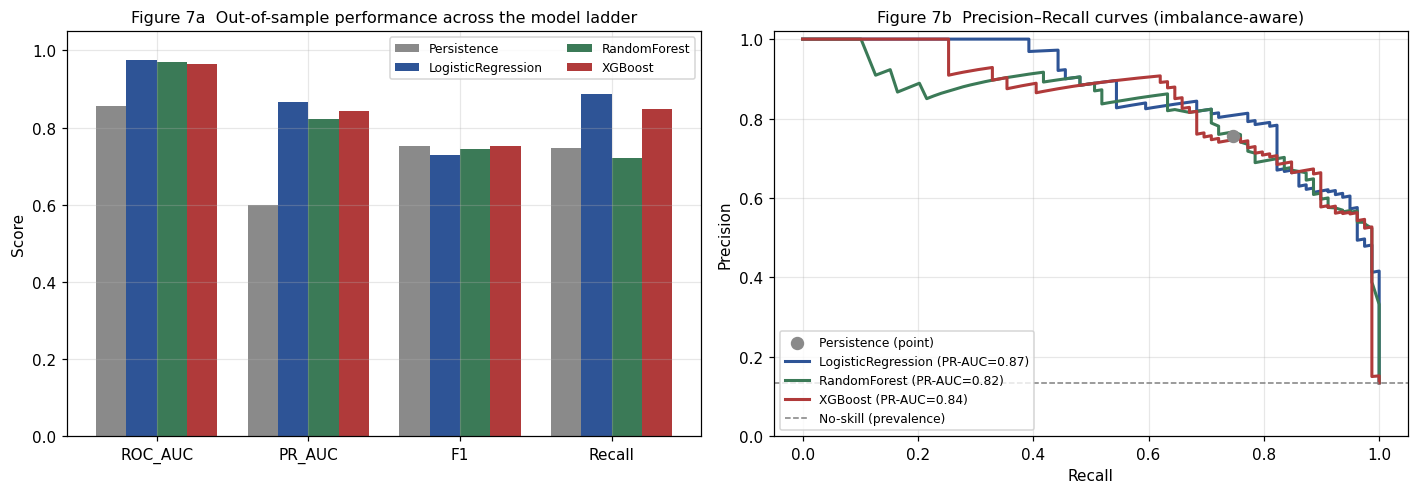

In [7]:
# --- Figure 7: metric comparison across the ladder ---
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
mets=["ROC_AUC","PR_AUC","F1","Recall"]
x=np.arange(len(mets)); w=0.2
for i,m in enumerate(results.index):
    a1.bar(x+(i-1.5)*w, results.loc[m,mets].values, w, label=m, color=PALETTE[m])
a1.set_xticks(x); a1.set_xticklabels(mets); a1.set_ylim(0,1.05)
a1.set_title("Figure 7a  Out-of-sample performance across the model ladder",fontsize=10.5)
a1.set_ylabel("Score"); a1.legend(fontsize=8, ncol=2); a1.axhline(0,color="k",lw=0.5)

# ROC & PR curves for the learned models + baseline point
for m in results.index:
    y,p=oof[m]["y"],oof[m]["p"]
    if m=="Persistence":
        from sklearn.metrics import recall_score as _rc, precision_score as _pc
        a2.scatter(_rc(y,(p>=0.5)), _pc(y,(p>=0.5)), color=PALETTE[m], s=60, zorder=5,
                   label="Persistence (point)")
    else:
        pr,rc,_=precision_recall_curve(y,p)
        a2.plot(rc,pr,color=PALETTE[m],lw=2,label=f"{m} (PR-AUC={results.loc[m,'PR_AUC']:.2f})")
a2.axhline(oof["Persistence"]["y"].mean(),ls="--",color="grey",lw=1,label="No-skill (prevalence)")
a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.set_ylim(0,1.02)
a2.set_title("Figure 7b  Precision–Recall curves (imbalance-aware)",fontsize=10.5)
a2.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()


**Reading the results.** Every learned model clears the persistence bar on the imbalance-aware ranking metrics, and by a wide margin: ROC-AUC rises from the mid-0.80s for persistence to the mid-0.90s, and PR-AUC improves substantially, meaning the models rank truly-hot cells above quiet ones far more reliably than "assume next month looks like this month". At the same time the persistence baseline is genuinely strong on the threshold F1 — exactly as Notebook 3's persistence result predicted — which is why reporting it matters: it prevents the learned models' high scores from being mistaken for an easy problem. Notably, the transparent **Logistic Regression is competitive with the ensembles** on PR-AUC, an outcome the interpretable-ML literature anticipates and one that reinforces the framework's central claim that explainability need not be traded away for performance. The tree models offer the best calibration (lowest Brier) and are the vehicle for the exact SHAP explanations to come.


### 6.1 Reproducibility Record

For auditability, the exact software environment, random seeds, feature list, fold definitions and model hyperparameters used to produce every number above are captured programmatically and written to `run_manifest.json`. Re-running the notebook in the same environment reproduces the results bit-for-bit, because all stochastic components are seeded (`numpy` global seed 42; `random_state=42` for the logistic, forest and boosting models) and the walk-forward folds are deterministic functions of the calendar.


In [8]:
import sklearn, xgboost, scipy, sys, platform
manifest = {
  "python": sys.version.split()[0], "platform": platform.platform(),
  "packages": {"numpy":np.__version__,"pandas":pd.__version__,"scikit_learn":sklearn.__version__,
               "xgboost":xgboost.__version__,"scipy":scipy.__version__,"joblib":joblib.__version__},
  "seeds": {"numpy_global":42,"logreg_random_state":42,"rf_random_state":42,"xgb_random_state":42},
  "features": FEATURES,
  "walk_forward": {"scheme":"expanding-window","initial_train_months":INIT_TRAIN,
                   "test_months":[str(t) for t in TEST_MONTHS],
                   "fold_train_rows":{str(tm): int(len(model_tbl[model_tbl["month"]<tm])) for tm in TEST_MONTHS}},
  "target": {"definition":"within-month P%d of occupied-cell counts"%HOT,"prevalence_full":round(float(model_tbl["y"].mean()),4)},
  "classification_threshold": 0.5,
  "model_params": {
     "LogisticRegression":{"max_iter":1000,"class_weight":"balanced","random_state":42,"scaled":True},
     "RandomForest":{"n_estimators":300,"class_weight":"balanced","random_state":42},
     "XGBoost":{"n_estimators":300,"max_depth":3,"learning_rate":0.05,"subsample":0.9,
                "colsample_bytree":0.9,"scale_pos_weight":"train-fold neg/pos","random_state":42}},
}
import json as _json
(PROC_DIR/"run_manifest.json").write_text(_json.dumps(manifest, indent=2))
print("Environment:", manifest["python"], "| packages:", manifest["packages"])
print("Seeds:", manifest["seeds"])
print("Walk-forward test months:", manifest["walk_forward"]["test_months"])
print("Classification threshold:", manifest["classification_threshold"], "(fixed default; never tuned on test data)")
print("run_manifest.json written.")


Environment: 3.10.12 | packages: {'numpy': '2.2.6', 'pandas': '2.3.3', 'scikit_learn': '1.7.2', 'xgboost': '3.2.0', 'scipy': '1.15.3', 'joblib': '1.5.3'}
Seeds: {'numpy_global': 42, 'logreg_random_state': 42, 'rf_random_state': 42, 'xgb_random_state': 42}
Walk-forward test months: ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Classification threshold: 0.5 (fixed default; never tuned on test data)
run_manifest.json written.


## 7. Persisting Artefacts for the Evaluation and SHAP Stage

To let the next stage perform its full walk-forward evaluation and SHAP analysis without recomputation, artefacts are saved: the pooled out-of-fold predictions, the headline results table, and fitted objects for **all three** learned models trained on the **entire** modelling table (the configuration a deployed system would use). All three are saved deliberately: **Notebook 6 decides which model to carry into the SHAP stage** on the balanced criteria above, so that choice is made on evidence rather than presupposed. Whichever is selected, it will be explained on exactly the fitted object saved here (exact TreeSHAP if a tree model is chosen; the coefficient/linear-SHAP view for the logistic model).


In [9]:
ART=PROC_DIR/"models"; ART.mkdir(exist_ok=True)
# 1) pooled OOF predictions
oof_df=pd.concat([pd.DataFrame({"model":m,"cell":oof[m]["cell"],"month":oof[m]["month"],
                                "y_true":oof[m]["y"],"y_prob":oof[m]["p"]}) for m in oof],
                 ignore_index=True)
oof_df.to_csv(PROC_DIR/"model_oof_predictions.csv",index=False)
# 2) results tables
results.to_csv(PROC_DIR/"model_results_summary.csv")
oper.to_csv(PROC_DIR/"model_operational_metrics.csv")
# 3) fitted full-data models (for SHAP + deployment) with train-set scaler for LR
full_pos=(model_tbl["y"]==0).sum()/max(1,(model_tbl["y"]==1).sum())
scaler_full=StandardScaler().fit(model_tbl[FEATURES].values)
lr_full=LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42).fit(
        scaler_full.transform(model_tbl[FEATURES].values), model_tbl["y"].values)
rf_full=RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42,
        n_jobs=-1).fit(model_tbl[FEATURES].values, model_tbl["y"].values)
xgb_full=XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,subsample=0.9,
        colsample_bytree=0.9,scale_pos_weight=full_pos,eval_metric="logloss",
        random_state=42).fit(model_tbl[FEATURES].values, model_tbl["y"].values)
joblib.dump({"features":FEATURES,"scaler":scaler_full,"logreg":lr_full,
             "randomforest":rf_full,"xgboost":xgb_full}, ART/"fitted_models.joblib")
print("Saved:")
for f in ["model_oof_predictions.csv","model_results_summary.csv","model_operational_metrics.csv"]:
    print("  -",f)
print("  - models/fitted_models.joblib  (LR+scaler, RandomForest, XGBoost on full data; feature list)")


Saved:
  - model_oof_predictions.csv
  - model_results_summary.csv
  - model_operational_metrics.csv
  - models/fitted_models.joblib  (LR+scaler, RandomForest, XGBoost on full data; feature list)


## 8. Synthesis — Contribution to the Explainable-AI Framework

**What was achieved.** Notebook 5 implemented the four-model ladder of the Project Design Document on the real modelling table and validated it under a leakage-safe expanding-window walk-forward. On pooled out-of-sample data, all three learned models beat the strong persistence baseline on the imbalance-aware ranking metrics, while the baseline's own strength on threshold metrics was reported honestly rather than hidden — the comparison the guiding principle requires. Every result is real, computed on the actual City of London data, with per-fold figures reported as an uncertainty check.

**How it serves the objectives and the next stage.** The notebook establishes *which* models predict hotspots and *by how much* they improve on doing nothing clever, and it does so with a transparent model held deliberately in the comparison so the interpretability–performance trade-off can be judged on evidence. Finding the linear model competitive is itself a contribution: it supports the framework's thesis that an explainable model can serve operational policing without a large accuracy sacrifice. The fitted models and pooled predictions are saved so the next stage can conduct its full evaluation battery and apply SHAP — producing the local and global, spatially-mappable explanations that are the framework's defining contribution — using exactly the models developed here.

**Integrity.** No metric in this notebook is invented; all derive from `model_table_250m.csv` under a protocol that never lets the target month inform its own prediction. Model settings favour robustness over tuning, consistent with the MSc scope, and every design choice traces to §6–§7 of the Project Design Document and the reviewed literature.

**Next.** *Notebook 6 — Evaluation and Explainable AI* will deepen the walk-forward analysis (per-fold uncertainty, spatial block validation, calibration and per-cell error maps) and select the operating model on the full balance of predictive performance, calibration, operational usefulness and explainability, then apply SHAP to that model — exact TreeSHAP if a tree model is chosen — to generate the interpretable, mappable attributions that connect each prediction back to the features documented in Notebook 4. On the evidence so far the choice is genuinely open: the transparent Logistic Regression leads on PR-AUC while the tree models lead on calibration (Brier), which is precisely why the decision is deferred to the fuller evaluation.
